# Late-Fusion Error Analysis: R-GCN vs BioLinkBERT Hybrid Fusion

Standalone notebook that:
1. Loads PrimeKG (`nodes.csv`, `edges.csv`, `kg.csv`).
2. Loads the trained R-GCN cross-attention model from `best.pt` and computes the R-GCN-only baseline by scoring all drugs for every test disease.
3. Loads the fusion sweep CSV `feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.csv` (β ∈ {0.1, 0.2, 0.3}).
4. Runs an error analysis comparing R-GCN baseline vs fused predictions across β values, stratified by disease difficulty.

Edit `DATA_DIR`, `CKPT_NAME`, and `FUSION_CSV` in the config cell, then run top-to-bottom.

**Notes**
- The fusion CSV does not contain a pure R-GCN row, so the baseline is computed live from `best.pt`.
- β here is the LLM/text weight in `s_final = (1−β)·s_graph + β·s_LLM` (i.e. β = 0 would be pure R-GCN, β = 1 would be pure LLM). β = 0.1 means a small LLM contribution. *If your sweep used the opposite convention, just flip the interpretation throughout — the math is symmetric.*


In [ ]:
!pip install pandas numpy scipy networkx tqdm
import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
!pip install torch-geometric
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

PyTorch: 2.10.0+cpu, CUDA: False
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.3 MB/s eta 0:00:00


## 1. Configuration

In [ ]:
import os, gc, ast, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict
from torch_geometric.nn import RGCNConv
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import seaborn as sns

# ─── Paths (edit these) ──────────────────────────────────────────────
DATA_DIR   = "/content/drive/MyDrive/phenotype-drug/"
CKPT_NAME  = "best_model.pt"
FUSION_CSV = "feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.csv"

# ─── Constants (must match training) ─────────────────────────────────
INDICATION_REL = "indication"
PHENOTYPE_REL  = "disease_phenotype_positive"
DRUG_TYPE      = "drug"
PHENOTYPE_TYPE = "effect/phenotype"
SRC_COL        = "x_index"
DST_COL        = "y_index"
REL_COL        = "relation"

HIDDEN_DIM = 256
NUM_LAYERS = 3
NUM_BASES  = 15
NUM_HEADS  = 4
DROPOUT    = 0.2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Mounted at /content/drive
Device: cpu


## 2. Load PrimeKG and build mappings

In [ ]:
nodes = pd.read_csv(os.path.join(DATA_DIR, "nodes.csv"))
edges = pd.read_csv(os.path.join(DATA_DIR, "edges.csv"))
kg    = pd.read_csv(os.path.join(DATA_DIR, "kg.csv"))
print(f"Nodes: {nodes.shape}   Edges: {edges.shape}   KG triples: {kg.shape}")

# disease → phenotypes (undirected)
phen_edges = kg[kg[REL_COL] == PHENOTYPE_REL]
disease_to_phenotypes = defaultdict(set)
for _, row in phen_edges.iterrows():
    disease_to_phenotypes[row[SRC_COL]].add(row[DST_COL])
    disease_to_phenotypes[row[DST_COL]].add(row[SRC_COL])

# Train/test split
train_diseases = set(int(x.strip()) for x in
                     open(os.path.join(DATA_DIR, "train_disease_ids.txt")))
test_diseases  = set(int(x.strip()) for x in
                     open(os.path.join(DATA_DIR, "test_disease_ids.txt")))
test_pairs     = pd.read_csv(os.path.join(DATA_DIR, "test_drug_pairs.csv"))

test_disease_to_drugs = defaultdict(set)
for _, row in test_pairs.iterrows():
    test_disease_to_drugs[int(row["disease_id"])].add(int(row["drug_id"]))

drug_indices_arr = np.array(sorted(
    nodes[nodes["node_type"] == DRUG_TYPE]["node_index"].tolist()
))
print(f"Train: {len(train_diseases)}  Test: {len(test_diseases)}  Drugs: {len(drug_indices_arr)}")


/tmp/ipykernel_4023/1004318621.py:3: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg    = pd.read_csv(os.path.join(DATA_DIR, "kg.csv"))


Nodes: (129375, 5)   Edges: (8100498, 4)   KG triples: (8100498, 12)
Train: 431  Test: 108  Drugs: 7957


## 3. Build masked typed edge index (for the R-GCN forward pass)

In [ ]:
kg_train = kg[(~kg[SRC_COL].isin(test_diseases)) &
              (~kg[DST_COL].isin(test_diseases))]
print(f"KG edges after masking: {len(kg_train):,}  (was {len(kg):,})")

all_relations = sorted(kg_train[REL_COL].unique().tolist())
rel2id        = {r: i for i, r in enumerate(all_relations)}
NUM_ORIG_RELS = len(rel2id)

src_arr = kg_train[SRC_COL].values
dst_arr = kg_train[DST_COL].values
rel_arr = np.array([rel2id[r] for r in kg_train[REL_COL].values])

edge_src = np.concatenate([src_arr, dst_arr])
edge_dst = np.concatenate([dst_arr, src_arr])
edge_rel = np.concatenate([rel_arr, rel_arr + NUM_ORIG_RELS])

NUM_RELATIONS = NUM_ORIG_RELS * 2
NUM_NODES     = len(nodes)
edge_index = torch.tensor(np.stack([edge_src, edge_dst]),
                          dtype=torch.long, device=DEVICE)
edge_type  = torch.tensor(edge_rel, dtype=torch.long, device=DEVICE)
print(f"Nodes: {NUM_NODES:,}  Edges (with reverse): {edge_index.shape[1]:,}  Rels (×2): {NUM_RELATIONS}")


KG edges after masking: 8,081,958  (was 8,100,498)
Nodes: 129,375  Edges (with reverse): 16,163,916  Rels (×2): 60


## 4. Index → human-readable name lookups

In [ ]:
def _name_map(kg, type_label):
    x = kg[kg["x_type"] == type_label][["x_index", "x_name"]].drop_duplicates("x_index")
    y = (kg[kg["y_type"] == type_label][["y_index", "y_name"]]
         .rename(columns={"y_index": "x_index", "y_name": "x_name"})
         .drop_duplicates("x_index"))
    m = pd.concat([x, y]).drop_duplicates("x_index")
    return dict(zip(m["x_index"].astype(int), m["x_name"]))

idx_to_pheno_name   = _name_map(kg, "effect/phenotype")
idx_to_drug_name    = _name_map(kg, "drug")
idx_to_disease_name = _name_map(kg, "disease")
print(f"Name maps: {len(idx_to_pheno_name)} phenotypes, "
      f"{len(idx_to_drug_name)} drugs, {len(idx_to_disease_name)} diseases")


Name maps: 15311 phenotypes, 7957 drugs, 17080 diseases


## 5. R-GCN + cross-attention model definition

In [ ]:
USE_RESIDUAL = True   # flip to False if best.pt came from the no-residual ablation

class DrugConditionedCrossAttention(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads,
                                          dropout=dropout, batch_first=True)
        self.score_proj = nn.Linear(dim, 1)

    def forward(self, drug_emb, pheno_embs, pheno_mask=None):
        query = drug_emb.unsqueeze(1)
        attn_out, _ = self.attn(query, pheno_embs, pheno_embs,
                                key_padding_mask=pheno_mask)
        return self.score_proj(attn_out.squeeze(1)).squeeze(-1)


class PhenoDrugModel(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim,
                 num_bases=10, num_layers=2, num_heads=4, dropout=0.2,
                 use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(RGCNConv(hidden_dim, hidden_dim,
                                       num_relations=num_relations,
                                       num_bases=num_bases))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.cross_attn = DrugConditionedCrossAttention(hidden_dim, num_heads, dropout)
        self.dropout = dropout

    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight
        for conv, norm in zip(self.convs, self.norms):
            residual = x
            x = conv(x, edge_index, edge_type)
            x = norm(x); x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            if self.use_residual:
                x = x + residual
        return x

    def score(self, node_embs, drug_idx, pheno_idx, pheno_mask):
        return self.cross_attn(node_embs[drug_idx], node_embs[pheno_idx], pheno_mask)


## 6. Load `best.pt`

In [ ]:
model = PhenoDrugModel(
    num_nodes=NUM_NODES, num_relations=NUM_RELATIONS, hidden_dim=HIDDEN_DIM,
    num_bases=NUM_BASES, num_layers=NUM_LAYERS, num_heads=NUM_HEADS,
    dropout=DROPOUT, use_residual=USE_RESIDUAL,
).to(DEVICE)

ckpt_path = os.path.join(DATA_DIR, CKPT_NAME)
state = torch.load(ckpt_path, map_location=DEVICE)
missing, unexpected = model.load_state_dict(state, strict=False)
print(f"Loaded {ckpt_path}")
print(f"  Missing:    {len(missing)} (first: {missing[:2]})")
print(f"  Unexpected: {len(unexpected)} (first: {unexpected[:2]})")
print(f"  Params:     {sum(p.numel() for p in model.parameters()):,}")
model.eval()

with torch.no_grad():
    node_embs = model.encode(edge_index, edge_type)
print(f"node_embs: {tuple(node_embs.shape)}")


Loaded /content/drive/MyDrive/phenotype-drug/best_model.pt
  Missing:    0 (first: [])
  Unexpected: 0 (first: [])
  Params:     36,534,157
node_embs: (129375, 256)


## 7. Load the fusion sweep CSV

In [ ]:
fusion_path = os.path.join(DATA_DIR, FUSION_CSV)
fdf_raw = pd.read_csv(fusion_path)
print(f"Loaded {fusion_path}")
print(f"Shape: {fdf_raw.shape}")
print(f"Columns: {list(fdf_raw.columns)}")
fdf_raw.head(3)


Loaded /content/drive/MyDrive/phenotype-drug/feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.csv
Shape: (108, 18)
Columns: ['disease_idx', 'beta', 'n_phenotypes', 'n_true_drugs_ind', 'n_true_drugs_off', 'graph_margin', 'llm_margin', 'margin_gap', 'top10_jaccard', 'oracle_beta_ind', 'MRR', 'R@10', 'R@50', 'MRR_off', 'R@10_off', 'R@50_off', 'top10', 'top50_drug_ids']


,disease_idx,beta,n_phenotypes,n_true_drugs_ind,n_true_drugs_off,graph_margin,llm_margin,margin_gap,top10_jaccard,oracle_beta_ind,MRR,R@10,R@50,MRR_off,R@10_off,R@50_off,top10,top50_drug_ids
0,27219,0.2,73,2,2,0.157997,0.077740,0.080256,0.666667,0.0,1.0,0.500000,0.500000,1.0,0.500000,0.500000,"(14208, 14387, 14527, 14477, 14686, 14530, 143...","(14208, 14387, 14527, 14477, 14686, 14530, 143..."
1,27249,0.1,31,1,1,0.113991,0.064736,0.049255,0.111111,0.0,1.0,1.000000,1.000000,1.0,1.000000,1.000000,"(14208, 14387, 14530, 17215, 14527, 14477, 144...","(14208, 14387, 14530, 17215, 14527, 14477, 144..."
2,27361,0.3,48,14,14,0.112215,0.038473,0.073743,0.052632,0.0,1.0,0.357143,0.642857,1.0,0.357143,0.642857,"(16634, 15975, 14595, 17124, 14530, 14622, 201...","(16634, 15975, 14595, 17124, 14530, 14622, 201..."


In [ ]:
# Parse list-valued columns from string → list[int]
def _parse_id_list(s):
    if pd.isna(s):
        return []
    if isinstance(s, list):
        return [int(x) for x in s]
    s = str(s).strip()
    try:
        return [int(x) for x in ast.literal_eval(s)]
    except Exception:
        s2 = s.strip("()[]").replace(",", " ")
        return [int(t) for t in s2.split() if t.lstrip("-").isdigit()]

fdf = fdf_raw.copy()
for col in ["top10", "top50_drug_ids"]:
    if col in fdf.columns:
        fdf[col] = fdf[col].apply(_parse_id_list)

for c in ["MRR", "R@10", "R@50", "MRR_off", "R@10_off", "R@50_off",
          "graph_margin", "llm_margin", "margin_gap", "top10_jaccard",
          "beta", "n_phenotypes", "n_true_drugs", "n_true_drugs_off"]:
    if c in fdf.columns:
        fdf[c] = pd.to_numeric(fdf[c], errors="coerce")

disease_col = "disease_idx" if "disease_idx" in fdf.columns else "disease"
fdf["_disease"] = fdf[disease_col].astype(int)

print(f"Unique diseases: {fdf['_disease'].nunique()}")
print(f"Unique β values: {sorted(fdf['beta'].dropna().unique())}")
print("Rows per disease:")
print(fdf.groupby('_disease').size().describe())


Unique diseases: 108
Unique β values: [np.float64(0.1), np.float64(0.2), np.float64(0.3)]
Rows per disease:
count    108.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64


## 8. Fusion sweep: aggregate MRR / R@K vs β

This is the headline plot. β is the R-GCN weight (β = 1 ⇒ pure R-GCN). If the curve is monotonic with maximum at β = 1, fusion is hurting; an interior maximum is a fusion win.

In [ ]:
# Each disease has exactly one β assignment
assert fdf.groupby("_disease").size().max() == 1, \
    "Expected one row per disease, but some diseases have multiple β rows."

# Per-bucket aggregate metrics
agg = fdf.groupby("beta").agg(
    n_diseases=("MRR", "count"),
    MRR=("MRR", "mean"),
    R10=("R@10", "mean"),
    R50=("R@50", "mean"),
    MRR_off=("MRR_off", "mean"),
    R10_off=("R@10_off", "mean"),
    R50_off=("R@50_off", "mean"),
    margin_gap_mean=("margin_gap", "mean"),
    n_phenos_mean=("n_phenotypes", "mean"),
    n_true_drugs_mean=("n_true_drugs_off", "mean"),
    top10_jaccard_mean=("top10_jaccard", "mean"),
).reset_index().sort_values("beta")
print("Per-β-bucket statistics:")
print(agg.round(4).to_string(index=False))


Per-β-bucket statistics:
 beta  n_diseases    MRR    R10    R50  MRR_off  R10_off  R50_off  margin_gap_mean  n_phenos_mean  n_true_drugs_mean  top10_jaccard_mean
  0.1          35 0.3222 0.2544 0.4593   0.3625   0.2716   0.4715           0.0125        15.5429             8.1429              0.0553
  0.2          33 0.3036 0.2348 0.3079   0.3338   0.2413   0.3237           0.1478        23.7273             9.1212              0.0607
  0.3          40 0.2366 0.1624 0.3919   0.2856   0.1762   0.4276           0.1061        29.3250             8.2000              0.0581


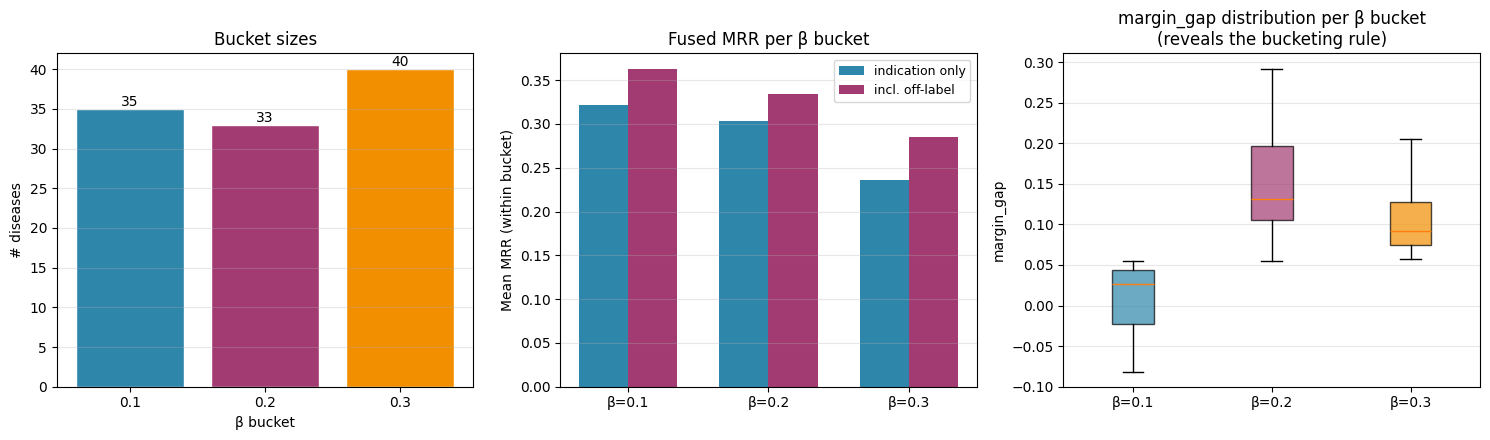

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) bucket sizes
ax = axes[0]
ax.bar(agg["beta"].astype(str), agg["n_diseases"],
       color=["#2E86AB", "#A23B72", "#F18F01"][:len(agg)],
       edgecolor="white")
for x, n in zip(agg["beta"].astype(str), agg["n_diseases"]):
    ax.text(x, n, str(int(n)), ha="center", va="bottom", fontsize=10)
ax.set_xlabel("β bucket"); ax.set_ylabel("# diseases")
ax.set_title("Bucket sizes")
ax.grid(alpha=0.3, axis="y")

# (b) MRR per bucket
ax = axes[1]
x = np.arange(len(agg))
w = 0.35
ax.bar(x - w/2, agg["MRR"],     w, label="indication only", color="#2E86AB")
ax.bar(x + w/2, agg["MRR_off"], w, label="incl. off-label", color="#A23B72")
ax.set_xticks(x); ax.set_xticklabels([f"β={b}" for b in agg["beta"]])
ax.set_ylabel("Mean MRR (within bucket)")
ax.set_title("Fused MRR per β bucket")
ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=9)

# (c) what drove the assignment? margin_gap distribution per bucket
ax = axes[2]
parts = [fdf[fdf["beta"] == b]["margin_gap"].dropna().values
         for b in sorted(fdf["beta"].unique())]
bp = ax.boxplot(parts, tick_labels=[f"β={b}" for b in sorted(fdf["beta"].unique())],
                patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"],
                    ["#2E86AB", "#A23B72", "#F18F01"][:len(parts)]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel("margin_gap")
ax.set_title("margin_gap distribution per β bucket\n(reveals the bucketing rule)")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("beta_buckets.png", dpi=160, bbox_inches="tight")
plt.show()


## 8b. Compute the pure R-GCN baseline from `best.pt`

The fusion CSV only contains β ∈ {0.1, 0.2, 0.3}, so we score every drug for every test disease using the trained model and compute MRR / R@10 / R@50 against the same ground truth as the fusion sweep.

This takes a couple of minutes on GPU because it's a 108-disease × 7,957-drug full sweep, batched in chunks of 512 drugs.

In [ ]:
from tqdm.auto import tqdm

def pad_pheno_batch(pheno_lists, device):
    max_len = max(len(p) for p in pheno_lists)
    B = len(pheno_lists)
    padded = torch.zeros(B, max_len, dtype=torch.long, device=device)
    mask   = torch.ones(B, max_len, dtype=torch.bool, device=device)
    for i, p in enumerate(pheno_lists):
        padded[i, :len(p)] = torch.tensor(p, dtype=torch.long)
        mask[i, :len(p)]   = False
    return padded, mask


def recall_at_k(ranked, true_set, k):
    if not true_set: return 0.0
    hits = sum(1 for d in ranked[:k] if d in true_set)
    return hits / len(true_set)


def reciprocal_rank(ranked, true_set):
    for i, d in enumerate(ranked, 1):
        if d in true_set:
            return 1.0 / i
    return 0.0


# Build off-label ground truth from kg.csv (off-label use edges)
off_label_edges = kg[kg[REL_COL] == "off-label use"]
test_disease_to_drugs_off = defaultdict(set)
# include indication ground truth too
for d, drugs in test_disease_to_drugs.items():
    test_disease_to_drugs_off[d] |= set(drugs)
# add off-label drugs (drug = x, disease = y)
for _, row in off_label_edges.iterrows():
    if int(row[DST_COL]) in test_diseases:
        test_disease_to_drugs_off[int(row[DST_COL])].add(int(row[SRC_COL]))


def score_disease(disease_idx, batch=512):
    """Score every drug for a single disease using the loaded R-GCN."""
    phenos = list(disease_to_phenotypes.get(disease_idx, []))
    if not phenos:
        return None
    all_drugs_t = torch.tensor(drug_indices_arr, dtype=torch.long, device=DEVICE)
    scores = []
    with torch.no_grad():
        for cs in range(0, len(drug_indices_arr), batch):
            ce = min(cs + batch, len(drug_indices_arr))
            cp, cm = pad_pheno_batch([phenos] * (ce - cs), DEVICE)
            sc = model.score(node_embs, all_drugs_t[cs:ce], cp, cm)
            scores.append(sc.cpu().numpy())
    scores = np.concatenate(scores)
    ranked = drug_indices_arr[np.argsort(-scores)].tolist()
    return scores, ranked


# Score every test disease (only those that appear in the fusion CSV)
csv_diseases = set(fdf["_disease"].unique())
target_diseases = sorted(set(test_diseases) & csv_diseases)
print(f"Scoring {len(target_diseases)} diseases with R-GCN…")

rgcn_rows = []
for d in tqdm(target_diseases):
    out = score_disease(d)
    if out is None:
        continue
    scores, ranked = out
    true_drugs     = test_disease_to_drugs.get(d, set())
    true_drugs_off = test_disease_to_drugs_off.get(d, set())
    rgcn_rows.append({
        "disease_idx": d,
        "MRR_rgcn":     reciprocal_rank(ranked, true_drugs),
        "R10_rgcn":     recall_at_k(ranked, true_drugs, 10),
        "R50_rgcn":     recall_at_k(ranked, true_drugs, 50),
        "MRR_rgcn_off": reciprocal_rank(ranked, true_drugs_off),
        "R10_rgcn_off": recall_at_k(ranked, true_drugs_off, 10),
        "R50_rgcn_off": recall_at_k(ranked, true_drugs_off, 50),
        "top10_rgcn":   ranked[:10],
        "top50_rgcn":   ranked[:50],
    })

rgcn_df = pd.DataFrame(rgcn_rows).set_index("disease_idx")
print(f"\nR-GCN baseline over {len(rgcn_df)} diseases:")
print(f"  MRR    : {rgcn_df['MRR_rgcn'].mean():.4f}")
print(f"  R@10   : {rgcn_df['R10_rgcn'].mean():.4f}")
print(f"  R@50   : {rgcn_df['R50_rgcn'].mean():.4f}")
print(f"  MRR_off: {rgcn_df['MRR_rgcn_off'].mean():.4f}")
print(f"  R@10_off: {rgcn_df['R10_rgcn_off'].mean():.4f}")
print(f"  R@50_off: {rgcn_df['R50_rgcn_off'].mean():.4f}")


Scoring 108 diseases with R-GCN…


  0%|          | 0/108 [00:00<?, ?it/s]


R-GCN baseline over 108 diseases:
  MRR    : 0.2000
  R@10   : 0.1739
  R@50   : 0.3342
  MRR_off: 0.2545
  R@10_off: 0.1874
  R@50_off: 0.3608


## 9. Per-disease Δ-MRR: where does fusion help vs hurt?

Compare each disease's best-fused MRR (over all β < 1) against its pure R-GCN MRR (β = 1). The distribution of Δ shows whether fusion benefits are concentrated on a few diseases or broadly distributed.

In [ ]:
# Each disease has exactly one fused row in the CSV
fused_per_disease = (fdf.set_index("_disease")
                     [["beta", "MRR", "R@10", "R@50",
                       "MRR_off", "R@10_off", "R@50_off", "top10"]]
                     .rename(columns={"beta": "assigned_beta",
                                      "MRR": "MRR_fused",
                                      "R@10": "R10_fused",
                                      "R@50": "R50_fused",
                                      "MRR_off": "MRR_fused_off",
                                      "R@10_off": "R10_fused_off",
                                      "R@50_off": "R50_fused_off",
                                      "top10": "top10_fused"}))

# Join live R-GCN baseline with the per-disease fusion result
cmp = (rgcn_df.join(fused_per_disease, how="inner")
       .reset_index()
       .rename(columns={"index": "disease_idx",
                        "_disease": "disease_idx"}))
if "disease_idx" not in cmp.columns:
    cmp = cmp.rename(columns={cmp.columns[0]: "disease_idx"})

cmp["delta_MRR"]     = cmp["MRR_fused"]     - cmp["MRR_rgcn"]
cmp["delta_R10"]     = cmp["R10_fused"]     - cmp["R10_rgcn"]
cmp["delta_R50"]     = cmp["R50_fused"]     - cmp["R50_rgcn"]
cmp["delta_MRR_off"] = cmp["MRR_fused_off"] - cmp["MRR_rgcn_off"]
cmp["disease_name"]  = cmp["disease_idx"].map(idx_to_disease_name)

n_helped = (cmp["delta_MRR"] > 0).sum()
n_hurt   = (cmp["delta_MRR"] < 0).sum()
n_tied   = (cmp["delta_MRR"] == 0).sum()
print(f"Diseases helped by fusion: {n_helped}")
print(f"Diseases hurt by fusion:   {n_hurt}")
print(f"Diseases tied:             {n_tied}")
print(f"Mean Δ-MRR:     {cmp['delta_MRR'].mean():+.4f}  "
      f"Median: {cmp['delta_MRR'].median():+.4f}")
print(f"Mean Δ-MRR_off: {cmp['delta_MRR_off'].mean():+.4f}  "
      f"Median: {cmp['delta_MRR_off'].median():+.4f}")


Diseases helped by fusion: 70
Diseases hurt by fusion:   24
Diseases tied:             14
Mean Δ-MRR:     +0.0848  Median: +0.0026
Mean Δ-MRR_off: +0.0707  Median: +0.0011


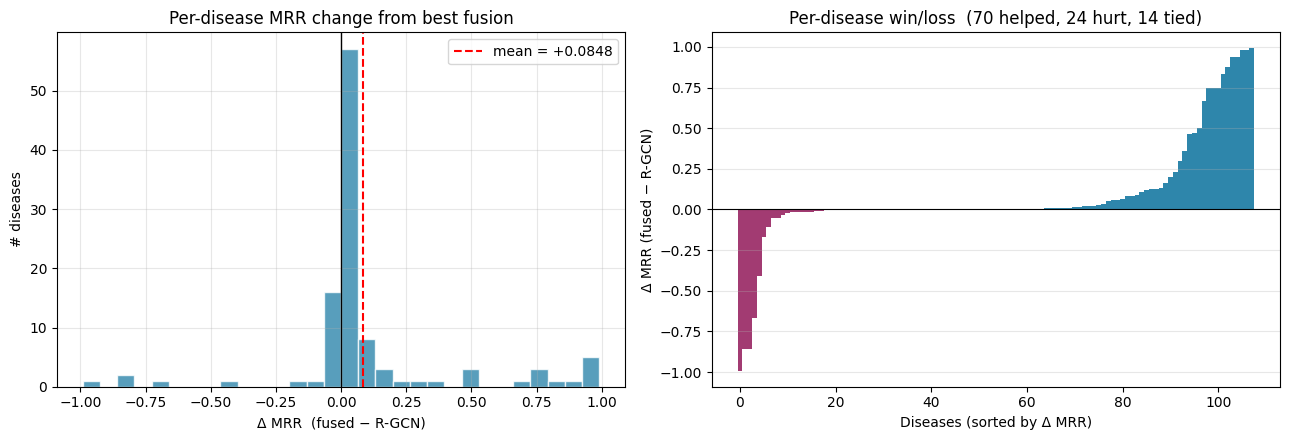


Top 10 helped:


KeyError: "['best_beta'] not in index"

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(cmp["delta_MRR"], bins=30, edgecolor="white", color="#2E86AB", alpha=0.8)
ax.axvline(0, color="black", lw=1)
ax.axvline(cmp["delta_MRR"].mean(), color="red", ls="--",
           label=f"mean = {cmp['delta_MRR'].mean():+.4f}")
ax.set_xlabel("Δ MRR  (fused − R-GCN)")
ax.set_ylabel("# diseases")
ax.set_title("Per-disease MRR change from best fusion")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
order = cmp.sort_values("delta_MRR")["delta_MRR"].values
colors = ["#A23B72" if v < 0 else "#2E86AB" if v > 0 else "gray" for v in order]
ax.bar(range(len(order)), order, color=colors, width=1.0)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Diseases (sorted by Δ MRR)")
ax.set_ylabel("Δ MRR (fused − R-GCN)")
ax.set_title(f"Per-disease win/loss  ({n_helped} helped, {n_hurt} hurt, {n_tied} tied)")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("delta_mrr.png", dpi=160, bbox_inches="tight")
plt.show()

print("\nTop 10 helped:")
print(cmp.nlargest(10, "delta_MRR")[
    ["disease_idx", "disease_name", "MRR_rgcn", "MRR_fused",
     "delta_MRR", "best_beta"]].to_string(index=False))
print("\nTop 10 hurt:")
print(cmp.nsmallest(10, "delta_MRR")[
    ["disease_idx", "disease_name", "MRR_rgcn", "MRR_fused",
     "delta_MRR", "best_beta"]].to_string(index=False))


In [ ]:
def _bucket(df, col, q=3):
    """Tertile-bucket with interval labels like '[1.0, 5.0]'.
       Robust to duplicate edges from heavily skewed columns."""
    _, edges = pd.qcut(df[col], q=q, duplicates="drop", retbins=True)
    n = len(edges) - 1
    if n < 2:
        return pd.Series(["all"] * len(df), index=df.index, dtype="category")

    # Build interval labels from the actual edges
    def _fmt(v):
        return f"{v:.2g}" if isinstance(v, float) else str(v)
    labels = [f"[{_fmt(edges[i])}, {_fmt(edges[i+1])}]" for i in range(n)]
    return pd.qcut(df[col], q=q, labels=labels, duplicates="drop")

In [ ]:
print(cmp["top10_jaccard"].describe())
print(cmp["top10_jaccard"].value_counts().head(10))

count    108.000000
mean       0.058003
std        0.106653
min        0.000000
25%        0.000000
50%        0.000000
75%        0.052632
max        0.666667
Name: top10_jaccard, dtype: float64
top10_jaccard
0.000000    61
0.052632    26
0.176471     8
0.111111     5
0.333333     4
0.250000     2
0.666667     1
0.428571     1
Name: count, dtype: int64


## 10. Stratified analysis: when does fusion help?

Bucket diseases by features available in the fusion CSV (`n_phenotypes`, `n_true_drugs`, `margin_gap`, `top10_jaccard`) and see where fusion gains are concentrated. The midterm hypothesis was that fusion helps cold-start (low `n_true_drugs`) cases — this is where to test it.

In [ ]:
# Disease features are already in cmp from the fused_per_disease join.
needed = ["n_phenotypes", "n_true_drugs_ind", "n_true_drugs_off",
          "margin_gap", "top10_jaccard"]
missing = [c for c in needed if c not in cmp.columns]
if missing:
    raise KeyError(f"Missing columns in cmp: {missing}")

def _bucket(df, col, q=3, labels=None):
    if labels is None:
        labels = ["low", "mid", "high"][:q]
    return pd.qcut(df[col], q=q, labels=labels, duplicates="drop")

# Jaccard is heavily zero-inflated — split into "no overlap" vs "any overlap"
cmp["bucket_jaccard"] = pd.Categorical(
    np.where(cmp["top10_jaccard"] == 0, "no overlap", "any overlap"),
    categories=["no overlap", "any overlap"], ordered=True,
)

print("Δ-MRR by phenotype-count tertile:")
print(cmp.groupby("bucket_n_phenos", observed=True)["delta_MRR"]
        .agg(["mean", "median", "count"]).round(4))
print("\nΔ-MRR by indication-drug-count tertile (cold-start = low):")
print(cmp.groupby("bucket_n_drugs", observed=True)["delta_MRR"]
        .agg(["mean", "median", "count"]).round(4))
print("\nΔ-MRR by margin-gap tertile:")
print(cmp.groupby("bucket_margin_gap", observed=True)["delta_MRR"]
        .agg(["mean", "median", "count"]).round(4))
print("\nΔ-MRR by top-10 Jaccard tertile:")
print(cmp.groupby("bucket_jaccard", observed=True)["delta_MRR"]
        .agg(["mean", "median", "count"]).round(4))

Δ-MRR by phenotype-count tertile:
                   mean  median  count
bucket_n_phenos                       
low              0.0998  0.0057     37
mid              0.0936  0.0005     36
high             0.0600  0.0001     35

Δ-MRR by indication-drug-count tertile (cold-start = low):
                  mean  median  count
bucket_n_drugs                       
low             0.0484  0.0003     36
mid             0.0550  0.0030     37
high            0.1537  0.0331     35

Δ-MRR by margin-gap tertile:
                     mean  median  count
bucket_margin_gap                       
low                0.1924  0.0141     36
mid               -0.0142  0.0001     36
high               0.0763  0.0008     36

Δ-MRR by top-10 Jaccard tertile:
                  mean  median  count
bucket_jaccard                       
no overlap      0.1144  0.0036     61
any overlap     0.0465  0.0001     47


/tmp/ipykernel_4023/2309246023.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=bcol, y="delta_MRR", ax=ax,
/tmp/ipykernel_4023/2309246023.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=bcol, y="delta_MRR", ax=ax,
/tmp/ipykernel_4023/2309246023.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=bcol, y="delta_MRR", ax=ax,
/tmp/ipykernel_4023/2309246023.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue`

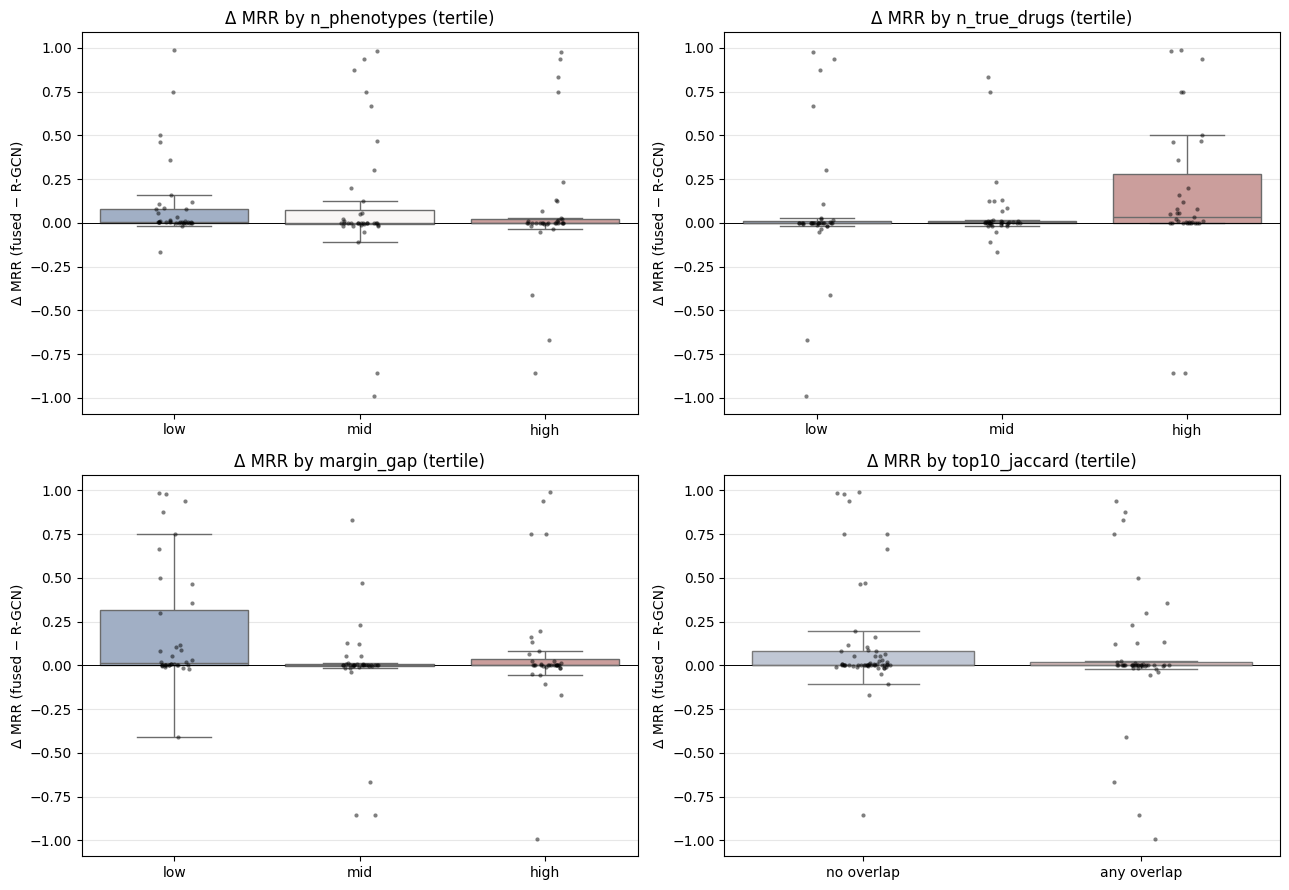

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
specs = [
    ("bucket_n_phenos",   "n_phenotypes (tertile)"),
    ("bucket_n_drugs",    "n_true_drugs (tertile)"),
    ("bucket_margin_gap", "margin_gap (tertile)"),
    ("bucket_jaccard",    "top10_jaccard (tertile)"),
]
for ax, (bcol, title) in zip(axes.flat, specs):
    sub = cmp.dropna(subset=[bcol])
    if sub.empty:
        ax.set_visible(False); continue
    sns.boxplot(data=sub, x=bcol, y="delta_MRR", ax=ax,
                palette="vlag", showfliers=False)
    sns.stripplot(data=sub, x=bcol, y="delta_MRR", ax=ax,
                  color="black", size=3, alpha=0.5)
    ax.axhline(0, color="black", lw=0.7)
    ax.set_title(f"Δ MRR by {title}")
    ax.set_xlabel(""); ax.set_ylabel("Δ MRR (fused − R-GCN)")
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("stratified_delta.png", dpi=160, bbox_inches="tight")
plt.show()


## 11. Continuous scatter: does fusion benefit correlate with margin gap?

If fusion helps when the LLM is more confident than the R-GCN, the points should slope downward (assuming `margin_gap = graph − llm`). The actual relationship tells you whether fusion is doing what theory predicts.

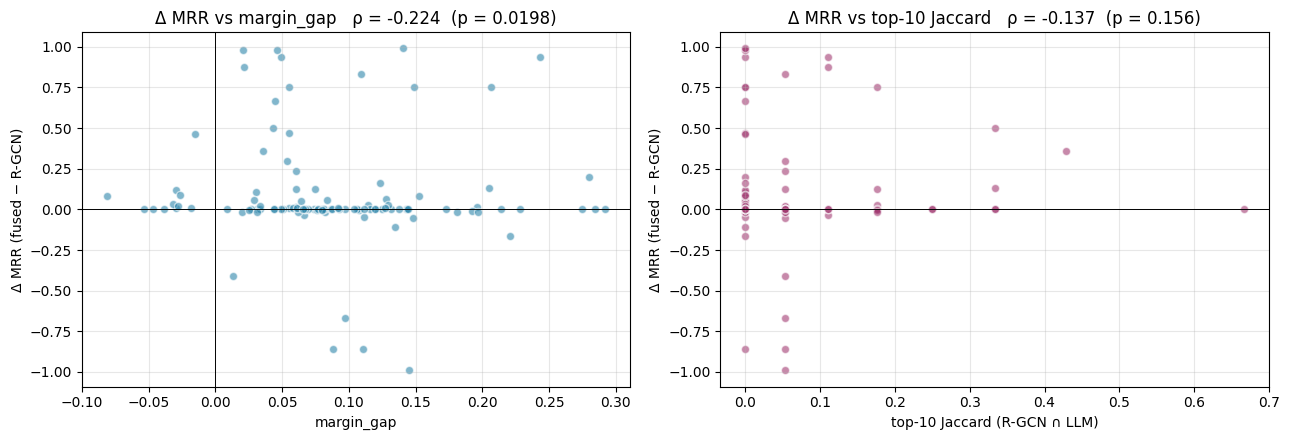

In [ ]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.scatter(cmp["margin_gap"], cmp["delta_MRR"],
           alpha=0.6, color="#2E86AB", edgecolor="white", s=35)
ax.axhline(0, color="black", lw=0.7); ax.axvline(0, color="black", lw=0.7)
rho, p = spearmanr(cmp["margin_gap"], cmp["delta_MRR"], nan_policy="omit")
ax.set_xlabel("margin_gap")
ax.set_ylabel("Δ MRR (fused − R-GCN)")
ax.set_title(f"Δ MRR vs margin_gap   ρ = {rho:.3f}  (p = {p:.3g})")
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(cmp["top10_jaccard"], cmp["delta_MRR"],
           alpha=0.6, color="#A23B72", edgecolor="white", s=35)
ax.axhline(0, color="black", lw=0.7)
rho2, p2 = spearmanr(cmp["top10_jaccard"], cmp["delta_MRR"], nan_policy="omit")
ax.set_xlabel("top-10 Jaccard (R-GCN ∩ LLM)")
ax.set_ylabel("Δ MRR (fused − R-GCN)")
ax.set_title(f"Δ MRR vs top-10 Jaccard   ρ = {rho2:.3f}  (p = {p2:.3g})")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("delta_scatter.png", dpi=160, bbox_inches="tight")
plt.show()


In [ ]:
# ───────────────────────────────────────────────────────────────────────
# Cold-start analysis: does fusion help when true drugs were unseen by R-GCN?
# ───────────────────────────────────────────────────────────────────────

# Drugs that R-GCN saw as positives during training (indication edges to
# train diseases — test-disease edges were already masked from kg_train,
# but we want positives, not just node presence).
train_pairs = pd.read_csv(os.path.join(DATA_DIR, "train_drug_pairs.csv"))
trained_drugs = set(train_pairs["drug_id"].astype(int))
print(f"Drugs seen in R-GCN training indications: {len(trained_drugs):,} "
      f"/ {len(drug_indices_arr):,} total")

# Per-disease cold-start fraction (over indication-only ground truth)
def cold_frac(disease_idx):
    true_drugs = test_disease_to_drugs.get(int(disease_idx), set())
    if not true_drugs:
        return np.nan
    n_cold = sum(1 for d in true_drugs if d not in trained_drugs)
    return n_cold / len(true_drugs)

cmp["cold_frac"] = cmp["disease_idx"].apply(cold_frac)

# Categorical view: all true drugs cold / some cold / none cold
def cold_cat(f):
    if pd.isna(f):       return "no_truth"
    if f == 1.0:         return "all_cold"
    if f == 0.0:         return "none_cold"
    return "some_cold"
cmp["cold_status"] = cmp["cold_frac"].apply(cold_cat)

print("\nDisease counts by cold-start status:")
print(cmp["cold_status"].value_counts())

print("\nΔ-MRR by cold-start status:")
print(cmp.groupby("cold_status")["delta_MRR"]
        .agg(["mean", "median", "count"]).round(4))

Drugs seen in R-GCN training indications: 1,212 / 7,957 total

Disease counts by cold-start status:
cold_status
none_cold    65
some_cold    32
all_cold     11
Name: count, dtype: int64

Δ-MRR by cold-start status:
               mean  median  count
cold_status                       
all_cold    -0.0491  0.0006     11
none_cold    0.0932  0.0012     65
some_cold    0.1137  0.0063     32


/tmp/ipykernel_4023/3451516091.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cmp[cmp["cold_status"].isin(order)],
/tmp/ipykernel_4023/3451516091.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{c}\n(n={counts.get(c,0)})" for c in order])


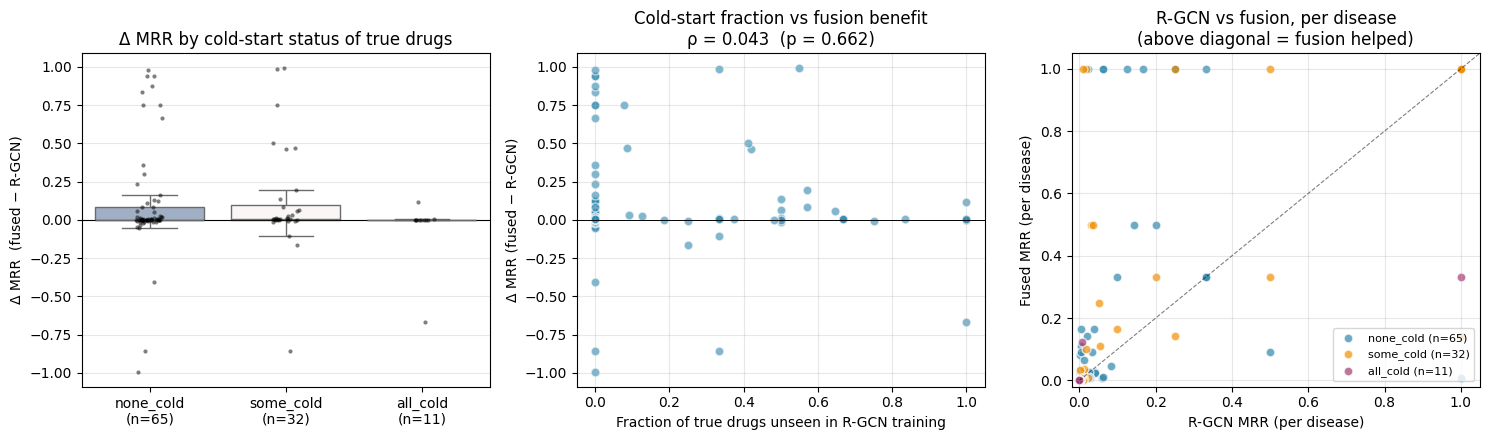


Mann-Whitney U (all_cold > none_cold): U=338, p=0.6163
  all_cold  (n=11): mean Δ-MRR = -0.0491
  none_cold (n=65): mean Δ-MRR = +0.0932


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Categorical: all_cold vs some_cold vs none_cold
ax = axes[0]
order = [c for c in ["none_cold", "some_cold", "all_cold"]
         if c in cmp["cold_status"].unique()]
sns.boxplot(data=cmp[cmp["cold_status"].isin(order)],
            x="cold_status", y="delta_MRR", order=order,
            palette="vlag", ax=ax, showfliers=False)
sns.stripplot(data=cmp[cmp["cold_status"].isin(order)],
              x="cold_status", y="delta_MRR", order=order,
              color="black", size=3, alpha=0.5, ax=ax)
ax.axhline(0, color="black", lw=0.8)
counts = cmp["cold_status"].value_counts().to_dict()
ax.set_xticklabels([f"{c}\n(n={counts.get(c,0)})" for c in order])
ax.set_ylabel("Δ MRR  (fused − R-GCN)")
ax.set_xlabel("")
ax.set_title("Δ MRR by cold-start status of true drugs")
ax.grid(alpha=0.3, axis="y")

# (b) Continuous scatter: cold_frac vs delta_MRR
ax = axes[1]
sub = cmp.dropna(subset=["cold_frac", "delta_MRR"])
ax.scatter(sub["cold_frac"], sub["delta_MRR"],
           alpha=0.6, color="#2E86AB", edgecolor="white", s=40)
ax.axhline(0, color="black", lw=0.7)
rho, p = spearmanr(sub["cold_frac"], sub["delta_MRR"])
ax.set_xlabel("Fraction of true drugs unseen in R-GCN training")
ax.set_ylabel("Δ MRR (fused − R-GCN)")
ax.set_title(f"Cold-start fraction vs fusion benefit\nρ = {rho:.3f}  (p = {p:.3g})")
ax.grid(alpha=0.3)

# (c) Head-to-head: pure-R-GCN MRR vs pure-fusion MRR, colored by cold status
ax = axes[2]
palette = {"none_cold": "#2E86AB", "some_cold": "#F18F01", "all_cold": "#A23B72"}
for status in order:
    sub = cmp[cmp["cold_status"] == status]
    ax.scatter(sub["MRR_rgcn"], sub["MRR_fused"],
               s=40, alpha=0.7, edgecolor="white",
               color=palette.get(status, "gray"),
               label=f"{status} (n={len(sub)})")
lim = max(cmp["MRR_rgcn"].max(), cmp["MRR_fused"].max(), 0.05) * 1.05
ax.plot([0, lim], [0, lim], "--", color="black", lw=0.8, alpha=0.5)
ax.set_xlim(-0.02, lim); ax.set_ylim(-0.02, lim)
ax.set_xlabel("R-GCN MRR (per disease)")
ax.set_ylabel("Fused MRR (per disease)")
ax.set_title("R-GCN vs fusion, per disease\n(above diagonal = fusion helped)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cold_start_analysis.png", dpi=160, bbox_inches="tight")
plt.show()

# Statistical test: is fusion gain in all_cold > none_cold?
if "all_cold" in cmp["cold_status"].values and "none_cold" in cmp["cold_status"].values:
    a = cmp[cmp["cold_status"] == "all_cold"]["delta_MRR"]
    b = cmp[cmp["cold_status"] == "none_cold"]["delta_MRR"]
    u, pval = mannwhitneyu(a, b, alternative="greater")
    print(f"\nMann-Whitney U (all_cold > none_cold): U={u:.0f}, p={pval:.4f}")
    print(f"  all_cold  (n={len(a)}): mean Δ-MRR = {a.mean():+.4f}")
    print(f"  none_cold (n={len(b)}): mean Δ-MRR = {b.mean():+.4f}")